# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [203]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [204]:
df = pd.read_csv(r"final_cleaned_aviation_flight_data.csv", encoding='latin-1', low_memory=False)
print("Dataset loaded succesfully")

print(f"The shape is :{df.shape}")

Dataset loaded succesfully
The shape is :(17892, 29)


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [205]:
#Small aircraft <= 20 passangers
#Large aircraft > 20 passangers

df["Aircraft.Size"] = df["Total.People"].apply(lambda x: "Small" if x <= 20 else "Large")

df["Aircraft.Size"].value_counts()

Aircraft.Size
Small    17019
Large      873
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [206]:
#small Aircraft
small =df[df["Aircraft.Size"] == "Small"]

small_make = ( small.groupby("Make").agg(Mean_Injury =("Fatal.Serious.Rate" , "mean") , Flights = ("Make", "size")).sort_values("Mean_Injury").multiply(100))

small_crafts = small_make.head(15)
small_crafts

,Mean_Injury,Flights
Make,,
BOMBARDIER INC,9.090909,2200
MCDONNELL DOUGLAS,9.404762,5500
BOMBARDIER,10.384615,2900
BOEING,14.197270,71700
AVIAT AIRCRAFT INC,16.447368,7600
MAULE,16.480620,21500
AYRES,20.370370,5500
GRUMMAN ACFT ENG COR-SCHWEIZER,20.689655,5800
STINSON,21.640827,12900


In [207]:
#Large Aircraft
large = df[df["Aircraft.Size"] == "Large"]

large_make = ( large.groupby("Make").agg(Mean_Injury =("Fatal.Serious.Rate" , "mean") , Flights = ("Make", "size")).sort_values("Mean_Injury").multiply(100))

large_crafts = small_make.head(15)
large_crafts

,Mean_Injury,Flights
Make,,
BOMBARDIER INC,9.090909,2200
MCDONNELL DOUGLAS,9.404762,5500
BOMBARDIER,10.384615,2900
BOEING,14.197270,71700
AVIAT AIRCRAFT INC,16.447368,7600
MAULE,16.480620,21500
AYRES,20.370370,5500
GRUMMAN ACFT ENG COR-SCHWEIZER,20.689655,5800
STINSON,21.640827,12900


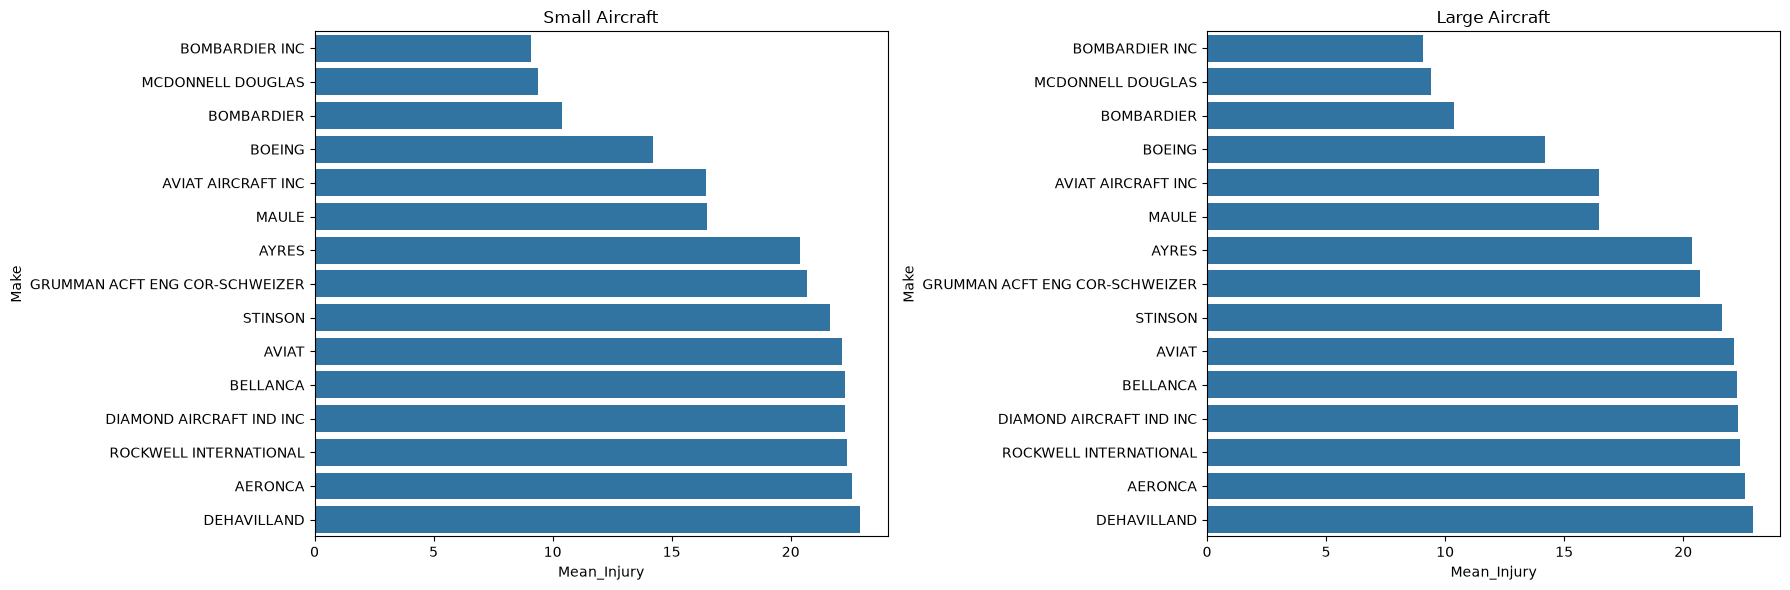

In [208]:
# Plot of the mean fatal/seriously injured fraction forboth small & large crafts adjacent

fig, axes = plt.subplots(1,2,figsize=(18,6))

sns.barplot(
    data=small_crafts.reset_index(),
    x="Mean_Injury",
    y="Make",
    ax=axes[0]
)

axes[0].set_title("Small Aircraft")

sns.barplot(
    data=large_crafts.reset_index(),
    x="Mean_Injury",
    y="Make",
    ax=axes[1]
)

axes[1].set_title("Large Aircraft")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

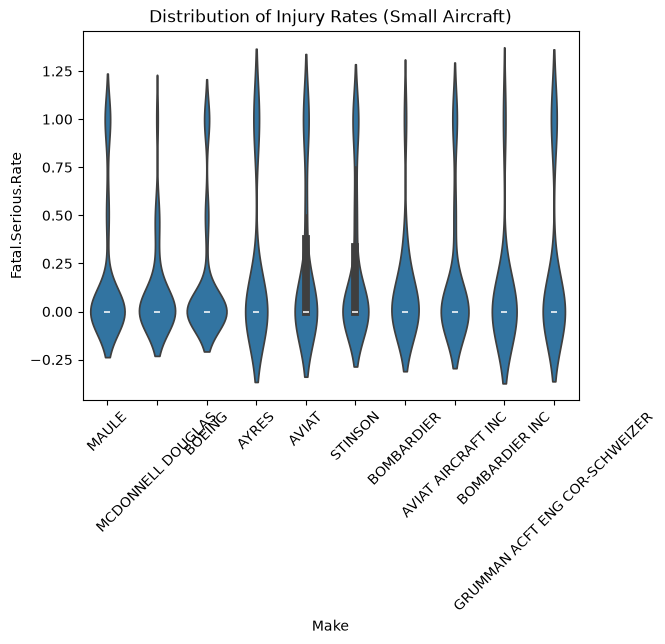

In [209]:
# Violin Plot for small aircrafts serious/fatally injured distribution

small_crafts_10 = small_crafts.head(10).index

sns.violinplot(
    data=small[small["Make"].isin(small_crafts_10)],
    x="Make",
    y="Fatal.Serious.Rate"
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Rates (Small Aircraft)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

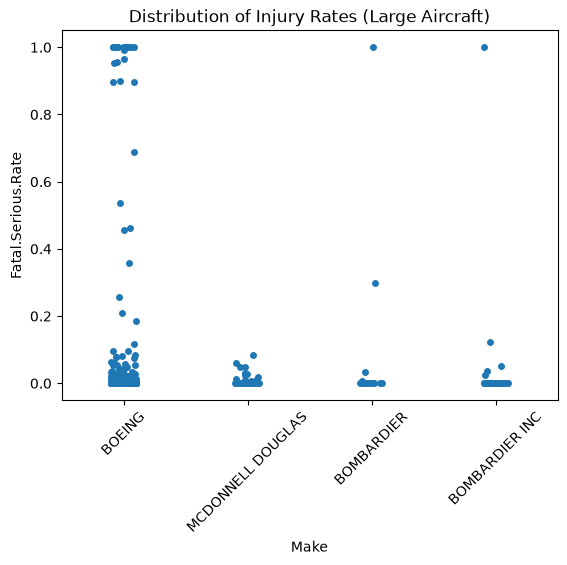

In [210]:
#Stripplot for large aircrafts serious/fataly injured distribution

large_crafts_10 = large_crafts.head(10).index

sns.stripplot(
    data=large[large["Make"].isin(large_crafts_10)],
    x="Make",
    y="Fatal.Serious.Rate",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Rates (Large Aircraft)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [211]:
#Rate of destruction for small aircrafts by Make
small_vulnerability = (
    small.groupby("Make")
    .agg(Destroyed=("Aircraft.Destroyed","mean"))
    .multiply(100)
    .sort_values("Destroyed")
    .head(15)
)

small_vulnerability

,Destroyed
Make,
LUSCOMBE,1.418440
GRUMMAN ACFT ENG COR-SCHWEIZER,1.724138
STINSON,2.325581
AIRBUS,2.400000
TAYLORCRAFT,3.225806
BOMBARDIER,3.448276
AERONCA,3.500000
BOEING,3.626220
AMERICAN CHAMPION AIRCRAFT,3.846154


In [212]:
#Rate of destruction for large aircrafts by Make
large_vulnerability = (
    large.groupby("Make")
    .agg(Destroyed=("Aircraft.Destroyed","mean"))
    .multiply(100)
    .sort_values("Destroyed")
    .head(15)
)

large_vulnerability

,Destroyed
Make,
DEHAVILLAND,0.000000
CESSNA,0.000000
PIPER,0.000000
GRUMMAN,0.000000
BOMBARDIER INC,2.325581
BOMBARDIER,4.761905
BOEING,4.936015
EMBRAER,5.128205
MCDONNELL DOUGLAS,7.547170


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

 #####       Reccomendations
-The right reccomendation would be to raise the insuarance fees on Dehavilland and Aeronca makes since they have the highest recorded injuries for both large and small aircrafts when an accident occurs. 
-I would also suggest raising the insuarance fees on Bombardier INC , Ayres, Aviat Aircraft INC since they have the highest rates of serious/ fatal injuries for the small aircrafts.
-Raise the insuarance fees on Boeing in the large aircraft categoty because it been been observed to have high serious/fatal injury rates.
-Raise the insuarance on the Bellanca for the small aircraft category since it has been observed to have a high rate of destruction when anaccident occurs.
-Increase the insuarance payment on the Beech for the large aircrafts because it has been spotted to have a very high destruction rate when an accident occurs.


 #####          Statistical Comments 
-Large aircrafts were seen to have high rates og injuries ideally due to size, capacity and the distance they travelled hence incresing the chances of high damage tothe craft , rate of injuries nad high number of injuries if an accident occurs.
-Small aircrafts were seen to have less rate of destruction due to size, number of engines and distance to travel hence they have less rates serious/fatal injuries.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [213]:
# Keep only aircraft types with at least 10 records
type_counts = df["Aircraft.Type"].value_counts()

valid_types = type_counts[type_counts >= 10].index

df = df[df["Aircraft.Type"].isin(valid_types)]

In [214]:
#Separate into Small and Large aircraft
small_planes = df[plane_df["Aircraft.Size"] == "Small"]
large_planes = df[plane_df["Aircraft.Size"] == "Large"]

**Larger planes**

In [215]:
large_summary = (
    large_planes
    .groupby("Aircraft.Type")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate", "mean"),
        Flights=("Aircraft.Type", "size")
    )
    .multiply(100)
    .sort_values("Mean_Injury")
)

large_summary

,Mean_Injury,Flights
Aircraft.Type,,
BOEING 747-400,0.000000,700
MCDONNELL DOUGLAS MD11,0.000000,100
CESSNA 172P,0.000000,100
CESSNA 172M,0.000000,100
BOEING 777,0.082099,3300
BOEING 757,0.147287,1800
BOEING 787,0.305832,1100
BOEING 737-7H4,0.324230,1200
BOMBARDIER INC CL-600-2B19,0.443122,1400


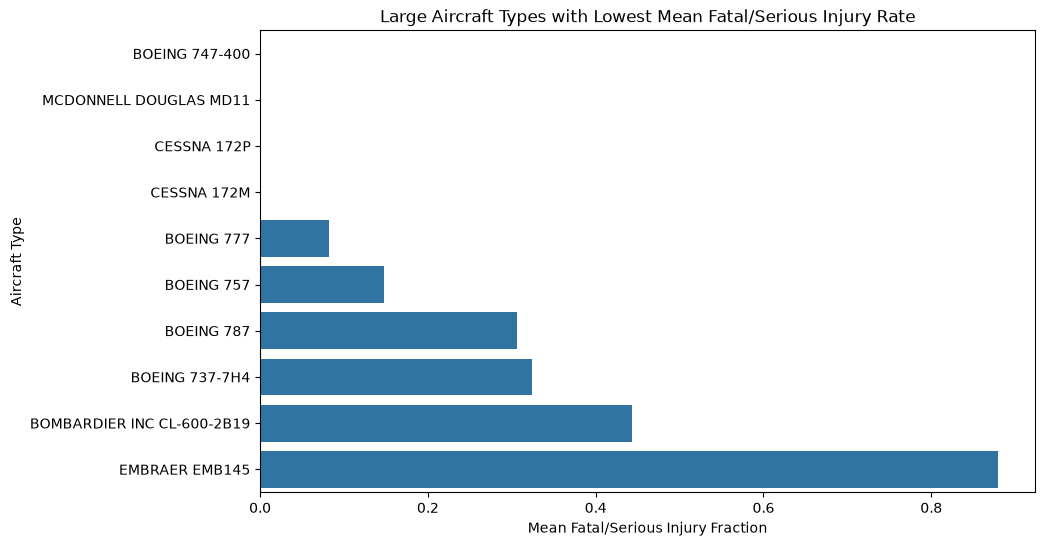

In [216]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=large_summary.head(10).reset_index(),
    x="Mean_Injury",
    y="Aircraft.Type"
)

plt.title("Large Aircraft Types with Lowest Mean Fatal/Serious Injury Rate")

plt.xlabel("Mean Fatal/Serious Injury Fraction")

plt.ylabel("Aircraft Type")

plt.show()

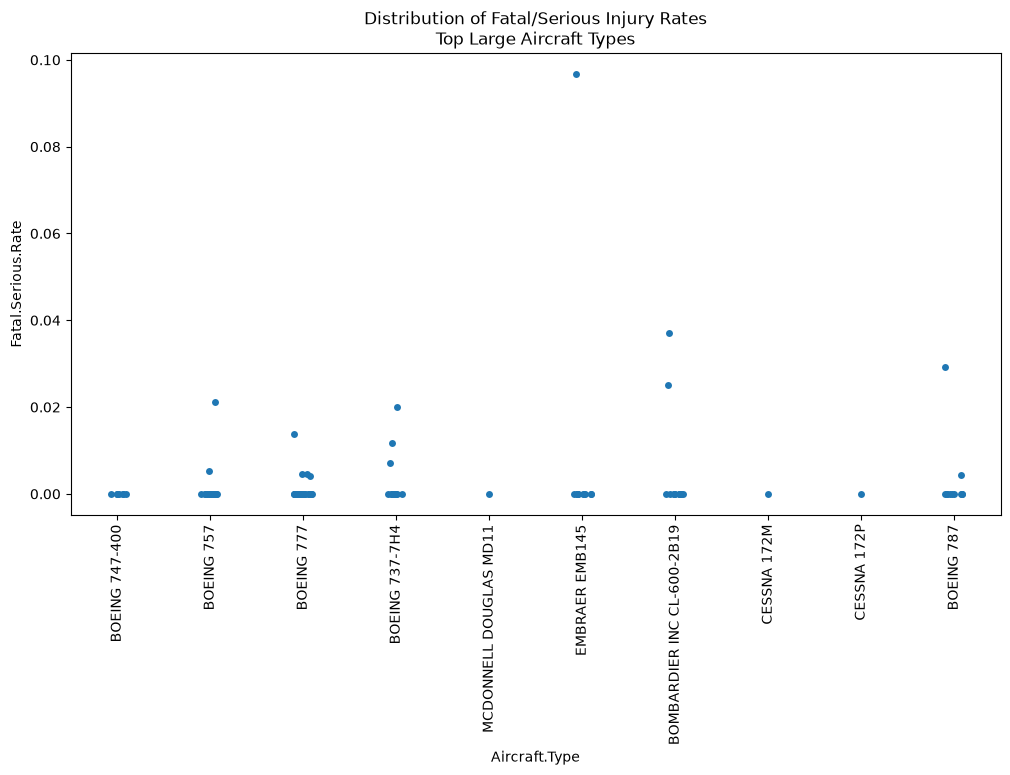

In [217]:
plt.figure(figsize=(12,6))

sns.stripplot(
    data=large_planes[
        large_planes["Aircraft.Type"].isin(
            large_summary.head(10).index
        )
    ],
    x="Aircraft.Type",
    y="Fatal.Serious.Rate",
    jitter=True
)

plt.xticks(rotation=90)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop Large Aircraft Types")

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [218]:
small_summary = (
    small_planes
    .groupby("Aircraft.Type")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate", "mean"),
        Flights=("Aircraft.Type", "size")
        )
    .multiply(100)
    .sort_values("Mean_Injury")
)

small_top10 = small_summary.tail(10)

small_top10

,Mean_Injury,Flights
Aircraft.Type,,
PIPER PA-32RT-300T,59.090909,1100
CESSNA 421C,60.000000,3000
BEECH A36TC,60.763889,2400
AIR TRACTOR AT502,61.111111,3700
CESSNA T303,71.296296,1000
BEECH P35,74.242424,1100
PIPER PA25,86.666667,3200
AIRBUS A319,NaN,500
AIRBUS A330,NaN,1600


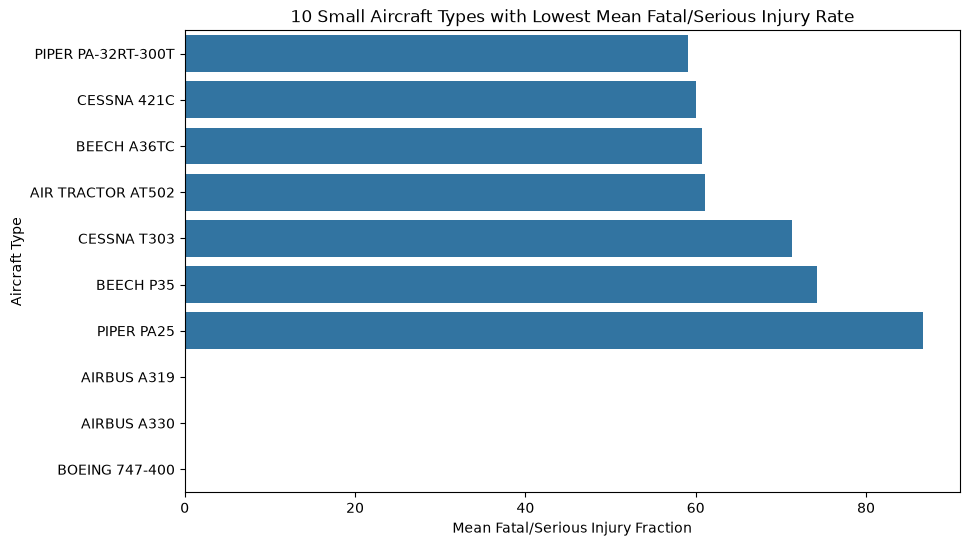

In [219]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=small_top10.reset_index(),
    x="Mean_Injury",
    y="Aircraft.Type"
)

plt.title("10 Small Aircraft Types with Lowest Mean Fatal/Serious Injury Rate")
plt.xlabel("Mean Fatal/Serious Injury Fraction")
plt.ylabel("Aircraft Type")

plt.show()

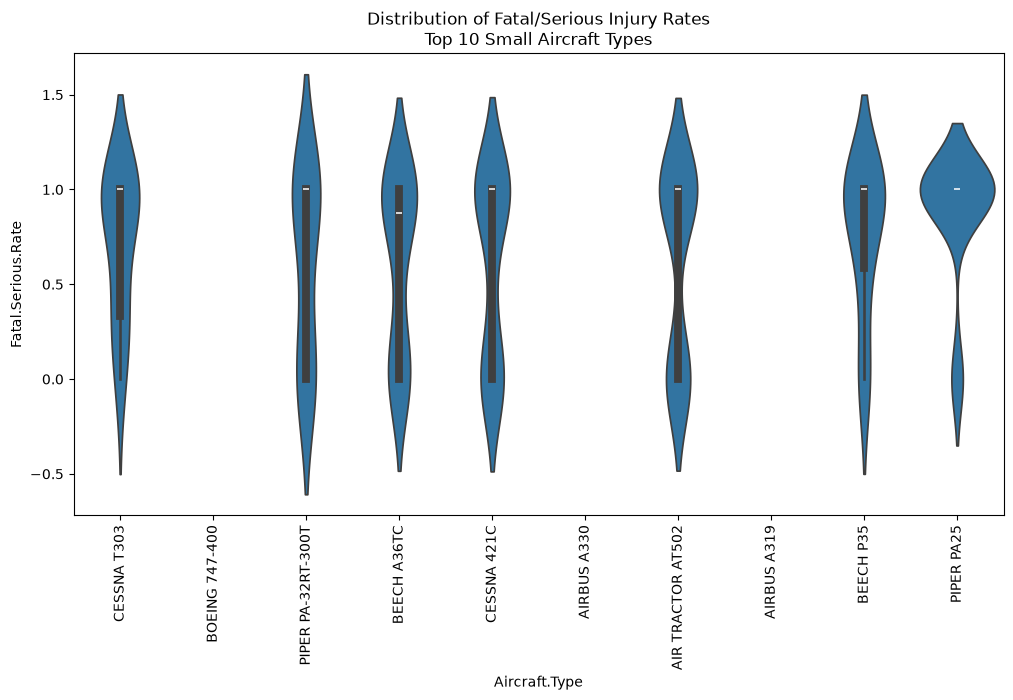

In [220]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_planes[
        small_planes["Aircraft.Type"].isin(small_top10.index)
    ],
    x="Aircraft.Type",
    y="Fatal.Serious.Rate"
)

plt.xticks(rotation=90)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop 10 Small Aircraft Types")

plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Analysis 1: Weather Condition

In [221]:
weather_summary = (
    df.groupby("Weather.Condition")
      .agg(
          Mean_Injury=("Fatal.Serious.Rate", "mean"),
          Destroyed_Rate=("Aircraft.Destroyed", "mean"),
          Accidents=("Weather.Condition", "size")
      )
      .sort_values("Mean_Injury")
)

weather_summary

,Mean_Injury,Destroyed_Rate,Accidents
Weather.Condition,,,
VMC,0.231058,0.065028,11226
IMC,0.671387,0.356815,653


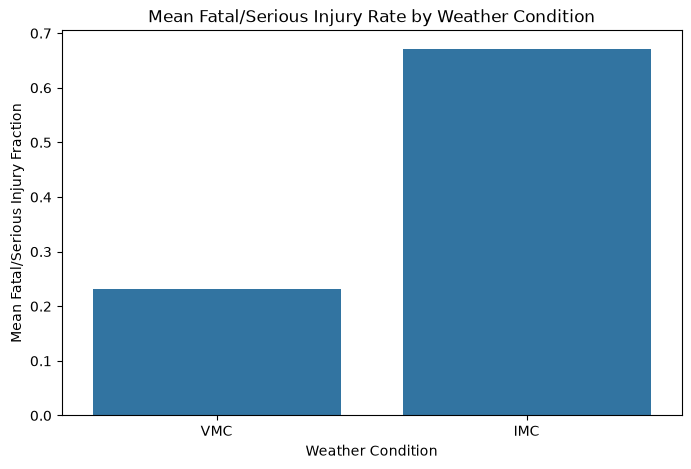

In [222]:
#Mean Fatal/Serious Injury Rate by Weather Condition"
plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Injury"
)

plt.title("Mean Fatal/Serious Injury Rate by Weather Condition")
plt.ylabel("Mean Fatal/Serious Injury Fraction")
plt.xlabel("Weather Condition")

plt.show()

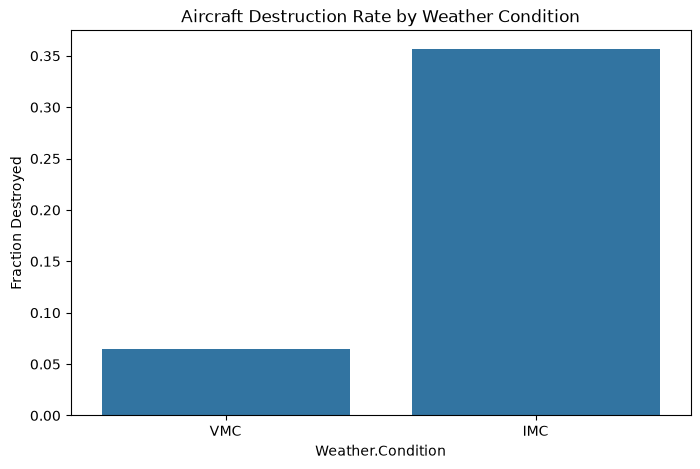

In [223]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Destroyed_Rate"
)

plt.title("Aircraft Destruction Rate by Weather Condition")
plt.ylabel("Fraction Destroyed")

plt.show()

VMC(Visual Meteorological Conditions)- Means weather is good enough primarily for pilots to able tofly and  look outside the aircraft using terrains, landmarks etc. for navigation
IMC(Instrument Meteorological Conditions) - Means weather is poor such that pilots cannot rely on outside referenes such as landmarks and terrains for navigation.


The inference is that when an accident occurs when it is IMC the fatalities is seen to be  very high as compared to when it is VMC.
When an accident occurs in VMC the aircraft damages are less as compared to IMC.
Both of the inferences are due to the fact that it is easier to navigate and do damage control if an incidence occurs if the pilots have clear visibility of the surrounding environments.

Analysis 2: Number of Engines

In [224]:
engine_summary = (
    df.groupby("Number.of.Engines")
      .agg(
          Mean_Injury=("Fatal.Serious.Rate", "mean"),
          Destroyed_Rate=("Aircraft.Destroyed", "mean"),
          Accidents=("Number.of.Engines", "size")
      )
      .sort_values("Number.of.Engines")
      .multiply(100)
)

engine_summary

,Mean_Injury,Destroyed_Rate,Accidents
Number.of.Engines,,,
0.0,0.000000,0.000000,200
1.0,25.534975,7.583630,1097100
2.0,29.240916,13.507291,130300
3.0,15.476190,16.666667,600
4.0,4.892532,3.030303,3300


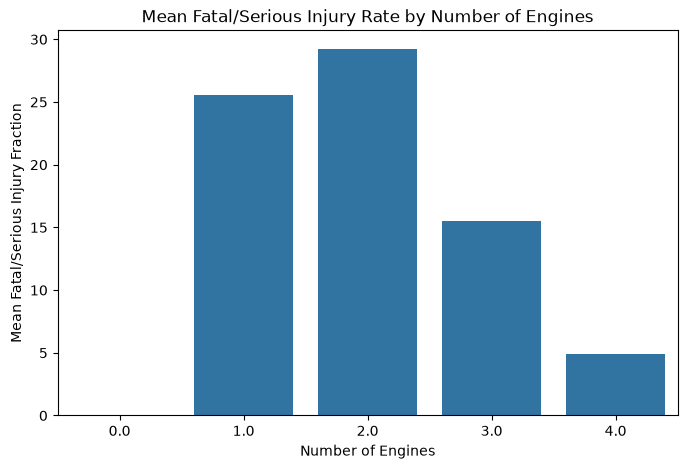

In [225]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=engine_summary.reset_index(),
    x="Number.of.Engines",
    y="Mean_Injury"
)

plt.title("Mean Fatal/Serious Injury Rate by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Mean Fatal/Serious Injury Fraction")

plt.show()

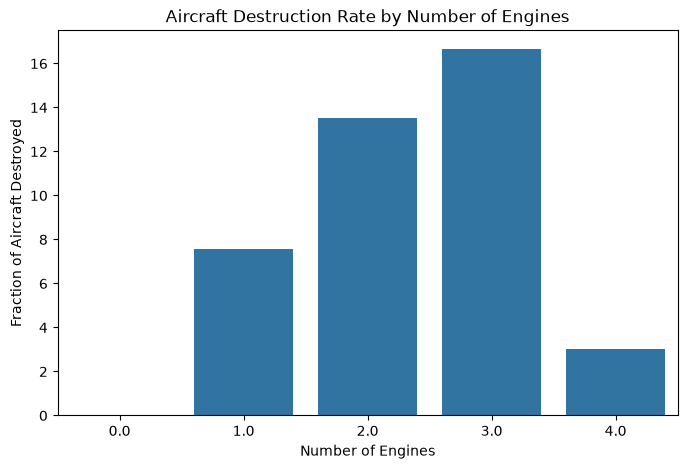

In [226]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=engine_summary.reset_index(),
    x="Number.of.Engines",
    y="Destroyed_Rate"
)

plt.title("Aircraft Destruction Rate by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Fraction of Aircraft Destroyed")

plt.show()

The inference is that with less number of engines accidents are more likely to occur since there is no back up and also a with increased number of engines incase an accident occurs it will cause a fatal injuries since there is likely more fuel and the damage is likely to be larger than if it was an accident by an aircraft with less number of engines.